# HDB Resale Price Prediction Model
### Predicts current market listing prices using XGBoost on historical HDB data
### Target: log-normalised price (removes floor area + market trend via RPI)

### 1. Imports & Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import getpass
import requests

import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

### 2. Live RPI Fetch (data.gov.sg API)

In [2]:
# -----------------------------------------------------------------------------
# RPI (Resale Price Index) is used to normalise prices during training
# and to convert model output back to dollar values at inference time.
# Fetching live ensures predictions always reflect the current market level
# without retraining the model.

def get_latest_rpi(fallback_rpi=203.6):
    """
    Fetches the latest HDB Resale Price Index from data.gov.sg.
    Falls back to a hardcoded value if the API is unavailable or times out.
    """
    try:
        api_key = "v2:bf99d83766f879f4ab4376967da335e257fa1e66c9ad871656b67ac7cd0f6807:Ds-P8VOyDi_iwynFpm0p3nlEQ0gm4mRG"
        url     = "https://data.gov.sg/api/action/datastore_search"
        headers = {"x-api-key": api_key}
        dataset = "d_14f63e595975691e7c24a27ae4c07c79"

        # Step 1: get total record count to find the last (most recent) entry
        total = requests.get(url, headers=headers, params={
            "resource_id": dataset, "limit": 1
        }, timeout=5).json()['result']['total']

        # Step 2: jump directly to the last record using offset
        record = requests.get(url, headers=headers, params={
            "resource_id": dataset, "limit": 1, "offset": total - 1
        }, timeout=5).json()['result']['records'][0]

        latest_rpi     = float(record['index'])
        latest_quarter = record['quarter']
        print(f"✓ Live RPI fetched: {latest_rpi} ({latest_quarter})")
        return latest_rpi

    except requests.exceptions.Timeout:
        print(f"⚠ RPI fetch timed out after 5s. Using fallback: {fallback_rpi}")
        return fallback_rpi

    except Exception as e:
        print(f"⚠ RPI fetch failed: {e}. Using fallback: {fallback_rpi}")
        return fallback_rpi

# CURRENT_RPI scales all predictions to today's market level.
# Update quarterly when HDB publishes new RPI — no retraining needed.
CURRENT_RPI = get_latest_rpi(fallback_rpi=203.6)

✓ Live RPI fetched: 203.6 (2025-Q4)


## 3. Load historical HDB resale transactions data to train model

In [4]:
# Navigate to project workspace
os.chdir('/workspaces/DSE3101-Project')

# Verify correct directory location 
print("Current directory:", os.getcwd())
print("Contents:", os.listdir('.'))

# Navigate to data/raw folder to obtain zip file that contains raw data
os.chdir('data/raw')
current_dir = os.getcwd()
print(f"Latest directory: {current_dir}")

Current directory: /workspaces/DSE3101-Project
Contents: ['docs', '.git', 'notebooks', '.DS_Store', 'models', 'frontend', 'requirements.txt', '.gitignore', '.vscode', 'backend', 'Final Web Scraper.ipynb', 'data', 'onemap_all_themes_full.json', 'README.md', 'onemap_all_themes_raw.txt']
Latest directory: /workspaces/DSE3101-Project/data/raw


In [5]:
hdb_df = pd.read_csv('HDB_full_resale_info.csv.gz', compression='gzip')

print(f"Dataframe shape: {hdb_df.shape}")

# Merge annual average RPI so each transaction has a market-level reference.
# Annual average (vs quarterly) smooths seasonal noise in the training target.
rpi_df = pd.read_csv('HousingAndDevelopmentBoardHDBResalePriceIndex1Q2009100Quarterly.csv')
rpi_long = rpi_df.melt(id_vars='DataSeries', var_name='quarter_str', value_name='RPI')
rpi_long = rpi_long[rpi_long['DataSeries'] == 'HDB Resale Price Index'].copy()
rpi_long['sold_year'] = rpi_long['quarter_str'].str[:4].astype(int)
rpi_annual = rpi_long.groupby('sold_year')['RPI'].mean().reset_index()

hdb_df = hdb_df.merge(rpi_annual, on='sold_year', how='left')
hdb_df = hdb_df.dropna(subset=['RPI'])

print(f"After dropping missing RPI: {hdb_df.shape}")
hdb_df.info()

Dataframe shape: (259143, 37)
After dropping missing RPI: (256457, 38)
<class 'pandas.DataFrame'>
RangeIndex: 256457 entries, 0 to 256456
Data columns (total 38 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   town                               256457 non-null  str    
 1   flat_type                          256457 non-null  str    
 2   block                              256457 non-null  str    
 3   street_name                        256457 non-null  str    
 4   storey_range                       256457 non-null  str    
 5   floor_area_sqm                     256457 non-null  float64
 6   flat_model                         256457 non-null  str    
 7   lease_commence_date                256457 non-null  int64  
 8   resale_price                       256457 non-null  float64
 9   remaining_lease                    256457 non-null  int64  
 10  sold_year                          256457 no

## 4. Exploratory Data Analysis

In [6]:
# Missing values
missing_values = hdb_df.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Drop duplicates
print(f"\nDuplicate rows: {hdb_df.duplicated().sum()}")
hdb_df = hdb_df.drop_duplicates()
duplicates_removed = hdb_df.duplicated().sum()
print(f"\nDuplicate rows remaining: {duplicates_removed}")

# Descriptive statistics
display(hdb_df[['floor_area_sqm', 'resale_price', 'remaining_lease', 'sold_year',
                'nearest_mrt_distance_m', 'num_amenities_within_1000m']].describe())

Missing values per column:
town                                 0
flat_type                            0
block                                0
street_name                          0
storey_range                         0
floor_area_sqm                       0
flat_model                           0
lease_commence_date                  0
resale_price                         0
remaining_lease                      0
sold_year                            0
address                              0
max_floor_lvl                        0
storey_mid                           0
storey_category                      0
region                               0
is_mature_estate                     0
latitude                             0
longitude                            0
matched_address                      0
status                               0
nearest_mrt_name                     0
nearest_mrt_distance_m               0
nearest_clinic_name                  0
nearest_clinic_distance_m            

,floor_area_sqm,resale_price,remaining_lease,sold_year,nearest_mrt_distance_m,num_amenities_within_1000m
count,256457.000000,2.564570e+05,256457.000000,256457.000000,256457.000000,256457.000000
mean,96.907870,5.124693e+05,74.222872,2020.401888,606.021257,22.941803
std,24.048654,1.829041e+05,13.737674,3.072595,368.976308,8.675089
min,31.000000,1.400000e+05,40.000000,2015.000000,34.000000,3.000000
25%,81.000000,3.780000e+05,63.000000,2018.000000,322.400000,17.000000
50%,93.000000,4.780000e+05,74.000000,2021.000000,536.600000,22.000000
75%,112.000000,6.150000e+05,87.000000,2023.000000,808.400000,28.000000
max,366.700000,1.658888e+06,98.000000,2025.000000,3574.500000,67.000000


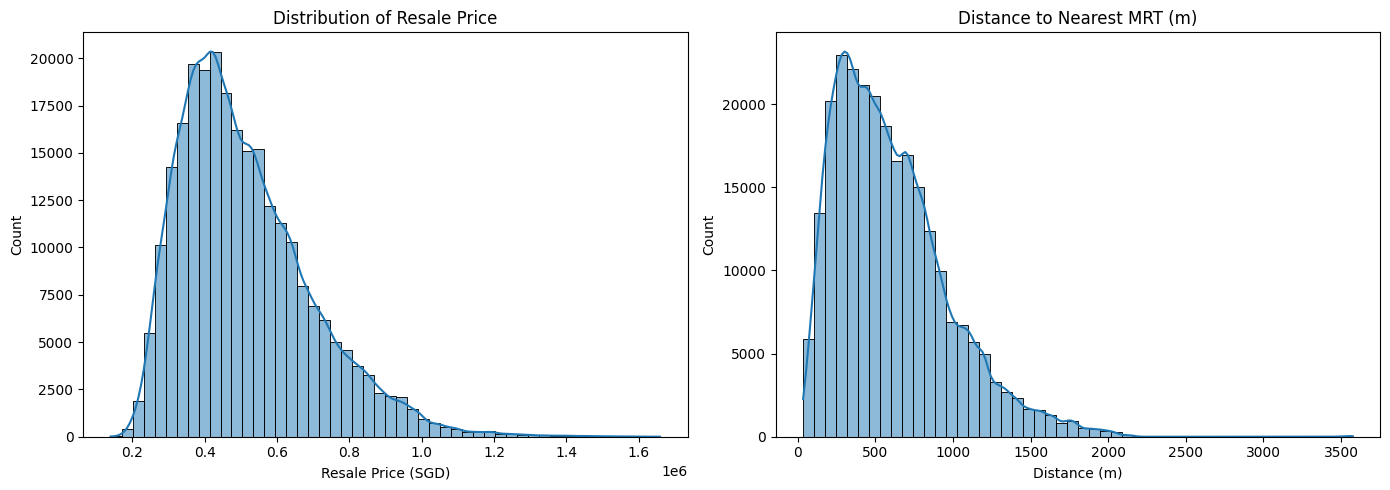

In [7]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(hdb_df['resale_price'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('Distribution of Resale Price')
axes[0].set_xlabel('Resale Price (SGD)')

sns.histplot(hdb_df['nearest_mrt_distance_m'], kde=True, bins=50, ax=axes[1])
axes[1].set_title('Distance to Nearest MRT (m)')
axes[1].set_xlabel('Distance (m)')

plt.tight_layout()
plt.show()

## 5. Feature Engineering & Target Construction

In [8]:
df_model = hdb_df.copy()

# --- Flat age at sale ---
df_model['flat_age_at_sale'] = df_model['sold_year'] - df_model['lease_commence_date']

# --- Normalized log target: remove floor area and time trend via RPI, so the model learns the true price drivers ---
df_model['log_price_norm'] = np.log(df_model['resale_price'] / (df_model['floor_area_sqm'] * df_model['RPI']))

# --- Drop columns: identifiers, leaky, redundant, unavailable or raw target ---
cols_to_drop = [
    # Identifiers and raw text
    'address', 'block', 'street_name', 'matched_address',
    'status', 'sold_year_month', 'year', 
    'lease_commence_date',  # collinear with remaining_lease
    'flat_age_at_sale',     # collinear with remaining_lease
    # Facility info (strings, not useful for model)
    'nearest_mrt_name', 'nearest_clinic_name', 'nearest_park_name',
    'nearest_community_club_name', 'nearest_hawker_name', 
    # Raw coordinates (location already captured by town/region
    # and spatial distance features)
    'latitude', 'longitude',
    # Target and RPI (used only to construct log_price_norm)
    'resale_price', 'RPI',
    # NOT available in PropertyGuru listings
    'flat_model',     # HDB architectural model not listed
    'storey_range',   # Replaced by storey_mid + storey_category
    'storey_mid',     # Replaced by storey_category
]

df_model = df_model.drop(columns=[c for c in cols_to_drop if c in df_model.columns])

# --- Encode categorical columns ---
categorical_cols = [
    c for c in df_model.select_dtypes(
        include=['object', 'category']
    ).columns.tolist()
    if c != 'log_price_norm'
]
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

print(f"Preprocessed shape: {df_model.shape}")
print(f"Columns: {df_model.columns.tolist()}")

Preprocessed shape: (256457, 21)
Columns: ['town', 'flat_type', 'floor_area_sqm', 'remaining_lease', 'sold_year', 'max_floor_lvl', 'storey_category', 'region', 'is_mature_estate', 'nearest_mrt_distance_m', 'nearest_clinic_distance_m', 'nearest_park_distance_m', 'nearest_community_club_distance_m', 'nearest_hawker_distance_m', 'num_mrt_within_1000m', 'num_clinic_within_1000m', 'num_park_within_1000m', 'num_community_club_within_1000m', 'num_hawker_within_1000m', 'num_amenities_within_1000m', 'log_price_norm']


/tmp/ipykernel_18149/4292543935.py:34: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  c for c in df_model.select_dtypes(


## 6. Train / Test Split

In [9]:
# Define feature list (everything except the target)
TREE_FEATURES = [c for c in df_model.columns if c != 'log_price_norm']

# ============================================================
# Time-based split (not random) — train on pre-2023 data, test on 2023+.
# This mirrors real-world deployment where the model predicts future prices
# from past patterns, preventing future data leakage into training.
# ============================================================
train_mask = df_model['sold_year'] < 2023
test_mask  = df_model['sold_year'] >= 2023

X_train = df_model.loc[train_mask, TREE_FEATURES]
X_test  = df_model.loc[test_mask,  TREE_FEATURES]
y_train = df_model.loc[train_mask, 'log_price_norm']
y_test  = df_model.loc[test_mask,  'log_price_norm']
      
# Current RPI for converting log predictions back to dollar-value actuals for interpretable evaluation metrics
y_train_actual = np.exp(y_train) * X_train['floor_area_sqm'] * CURRENT_RPI
y_test_actual = np.exp(y_test) * X_test['floor_area_sqm'] * CURRENT_RPI

print(f"Training set: {X_train.shape[0]:,} rows "
      f"(up to year {df_model.loc[train_mask, 'sold_year'].max()})")
print(f"Test set:     {X_test.shape[0]:,} rows "
      f"(from year {df_model.loc[test_mask, 'sold_year'].min()} onwards)")
print(f"Features:     {len(TREE_FEATURES)}")
print(f"\nFeature list:")
for f in TREE_FEATURES:
    print(f"  {f}")         

Training set: 178,537 rows (up to year 2022)
Test set:     77,920 rows (from year 2023 onwards)
Features:     20

Feature list:
  town
  flat_type
  floor_area_sqm
  remaining_lease
  sold_year
  max_floor_lvl
  storey_category
  region
  is_mature_estate
  nearest_mrt_distance_m
  nearest_clinic_distance_m
  nearest_park_distance_m
  nearest_community_club_distance_m
  nearest_hawker_distance_m
  num_mrt_within_1000m
  num_clinic_within_1000m
  num_park_within_1000m
  num_community_club_within_1000m
  num_hawker_within_1000m
  num_amenities_within_1000m


In [10]:
## Baseline: OLS Hedonic Regression
# OLS is run on the same log-normalised target and same train/test split
# as XGBoost. Categorical variables are one-hot encoded since OLS cannot
# handle label-encoded integers meaningfully.

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# Identify categorical columns for one-hot encoding
# (same cols as label-encoded, but OLS needs dummies)
ols_categorical = categorical_cols
ols_numeric = [c for c in TREE_FEATURES if c not in ols_categorical]

# Build preprocessing + OLS pipeline
preprocessor = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ols_categorical),
    ('passthrough', 'passthrough', ols_numeric),
])

ols_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('ols', LinearRegression())
])

# Use original un-label-encoded data for OLS (need raw strings for OneHotEncoder)
# Re-extract from hdb_df using the same train/test indices
X_train_raw = hdb_df.loc[X_train.index, TREE_FEATURES].copy()
X_test_raw  = hdb_df.loc[X_test.index,  TREE_FEATURES].copy()

# Drop any rows where raw categoricals might be missing
X_train_raw = X_train_raw.fillna('Unknown')
X_test_raw  = X_test_raw.fillna('Unknown')

ols_pipeline.fit(X_train_raw, y_train)

# Evaluate in dollar space (same as XGBoost evaluation)
ols_log_preds   = ols_pipeline.predict(X_test_raw)
ols_dollar_preds = np.exp(ols_log_preds) * X_test['floor_area_sqm'] * CURRENT_RPI

ols_mae  = mean_absolute_error(y_test_actual, ols_dollar_preds)
ols_mape = mean_absolute_percentage_error(y_test_actual, ols_dollar_preds) * 100
ols_rmse = np.sqrt(mean_squared_error(y_test_actual, ols_dollar_preds))

print("=== OLS Baseline (Hedonic Regression) ===")
print(f"MAE:  ${ols_mae:,.2f}")
print(f"MAPE: {ols_mape:.2f}%")
print(f"RMSE: ${ols_rmse:,.2f}")

# Print top coefficients by absolute magnitude for interpretability
feature_names = (
    ols_pipeline.named_steps['preprocessor']
    .named_transformers_['onehot']
    .get_feature_names_out(ols_categorical).tolist()
    + ols_numeric
)
coef_series = pd.Series(
    ols_pipeline.named_steps['ols'].coef_,
    index=feature_names
).sort_values(key=abs, ascending=False)

print("\nTop 15 OLS Coefficients (log-price units):")
print(coef_series.head(15).round(4).to_string())


=== OLS Baseline (Hedonic Regression) ===
MAE:  $47,246.97
MAPE: 7.34%
RMSE: $63,125.86

Top 15 OLS Coefficients (log-price units):
flat_type_MULTI-GENERATION    0.1932
is_mature_estate              0.1672
town_BUKIT TIMAH              0.1506
town_SEMBAWANG               -0.1340
town_MARINE PARADE            0.1334
region_OCR                   -0.1127
flat_type_3 ROOM             -0.1045
region_CCR                    0.1003
town_SERANGOON                0.0974
town_CLEMENTI                 0.0947
town_GEYLANG                 -0.0944
flat_type_4 ROOM             -0.0941
flat_type_1 ROOM              0.0915
town_WOODLANDS               -0.0871
town_TOA PAYOH               -0.0851


### 7. Model Training

In [11]:
# ============================================================
# Upweight recent transactions more heavily
# because recent market conditions are most relevant
# for predicting current listing prices
# ============================================================
# Sample weights — for better training focus on recent market
sample_weights = 1 + (X_train['sold_year'] - X_train['sold_year'].min()) / \
                     (X_train['sold_year'].max() - X_train['sold_year'].min())

# This gives weight 1.0 to oldest year, 2.0 to most recent training year

# Regularisation parameters prevent overfitting on the large training set.
# Early stopping halts training when test RMSE stops improving.
xgb_model = xgb.XGBRegressor(
    n_estimators        = 3000,   # Large tree budget; early stopping prevents overfitting
    learning_rate       = 0.02,   # Slow learning rate for better generalisation; 
                                  # each tree contributes small corrections

    max_depth           = 7,      # Moderate tree depth to capture interactions without overfitting
    subsample           = 0.8,    # Each tree trained on 80% of rows — introduces diversity, 
                                  # reduces variance

    colsample_bytree    = 0.8,    # Each tree uses 80% of features — prevents any single feature
                                  # from dominating

    min_child_weight    = 5,      # Prevents splits on very small groups, 
                                  # improving generalisation on rare combinations

    gamma               = 0.1,    # Minimum loss reduction required to make a split — 
                                  # prunes unnecessary branches

    reg_alpha           = 0.1,    # L1 regularisation — encourages sparse feature weights
    reg_lambda          = 1.0,    # L2 regularisation — penalises large weights
    random_state        = 42,
    n_jobs              = -1,
    early_stopping_rounds = 50,   # Training halts if test RMSE does not 
                                  # improve for 50 consecutive rounds
    eval_metric         = 'rmse'
)

xgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print(f"\nTraining complete!")
print(f"Best iteration: {xgb_model.best_iteration}")

[0]	validation_0-rmse:0.20331
[100]	validation_0-rmse:0.08468
[200]	validation_0-rmse:0.07092
[300]	validation_0-rmse:0.06676
[400]	validation_0-rmse:0.06487
[500]	validation_0-rmse:0.06370
[600]	validation_0-rmse:0.06309
[700]	validation_0-rmse:0.06288
[800]	validation_0-rmse:0.06279
[900]	validation_0-rmse:0.06276
[1000]	validation_0-rmse:0.06271
[1064]	validation_0-rmse:0.06271

Training complete!
Best iteration: 1014


## 8. Evaluation

MAE:  $31,653.21
MAPE: 4.79%
RMSE: $44,126.92


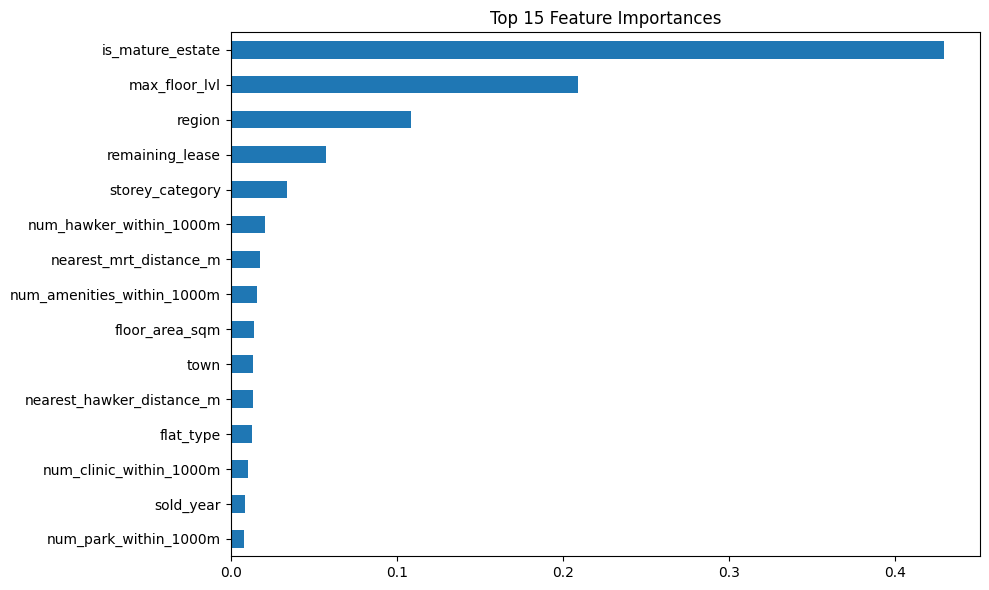


Top 10 features:
is_mature_estate              0.429595
max_floor_lvl                 0.209144
region                        0.108474
remaining_lease               0.057521
storey_category               0.033995
num_hawker_within_1000m       0.020691
nearest_mrt_distance_m        0.017536
num_amenities_within_1000m    0.016029
floor_area_sqm                0.014285
town                          0.013583
dtype: float32


In [12]:
# Predictions are converted from log-normalised space back to SGD
# using the current RPI — same inverse transform used at inference time.
final_log_preds = xgb_model.predict(X_test)
final_dollar_preds = np.exp(final_log_preds) * X_test['floor_area_sqm'] * CURRENT_RPI

mae  = mean_absolute_error(y_test_actual, final_dollar_preds)
mape = mean_absolute_percentage_error(y_test_actual, final_dollar_preds) * 100
rmse = np.sqrt(mean_squared_error(y_test_actual, final_dollar_preds))

print(f"MAE:  ${mae:,.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: ${rmse:,.2f}")

# Feature importance — reveals which signals the model relies on most
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=TREE_FEATURES
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(feat_imp.head(10))

## 9. Listing Premium Calibration

In [ ]:
# Per-town listing premium (transacted → asking price); PropertyGuru listings are asking prices, which are systematically higher.
# Empirically Derived from validation against real listings — premium areas get higher multiplier
# Update whenever new listing data is available.

TOWN_PREMIUM = {
    'MARINE PARADE':     1.17,
    'QUEENSTOWN':        1.15,
    'CLEMENTI':          1.11,
    'BUKIT MERAH':       1.10,
    'BUKIT PANJANG':     1.10,
    'HOUGANG':           1.09,
    'BEDOK':             1.08,
    'KALLANG/WHAMPOA':   1.08,
    'JURONG EAST':       1.07,
    'BUKIT BATOK':       1.07,
    'CENTRAL AREA':      1.07,
    'TAMPINES':          1.07,
    'JURONG WEST':       1.06,
    'CHOA CHU KANG':     1.06,
    'SERANGOON':         1.06,
    'TOA PAYOH':         1.06,
    'PASIR RIS':         1.05,
    'ANG MO KIO':        1.05,
    'WOODLANDS':         1.05,
    'SENGKANG':          1.05,
    'YISHUN':            1.05,
    'BISHAN':            1.04,
    'PUNGGOL':           1.04,
    'BUKIT TIMAH':       1.03,
    'GEYLANG':           1.03,
    'SEMBAWANG':         1.02,
}

DEFAULT_PREMIUM = 1.07

# Flat type adjustment on top of town premium
FLAT_TYPE_ADJUSTMENT = {
    '2 ROOM':           1.035,
    '3 ROOM':           1.014,
    'EXECUTIVE':        1.008,
    '4 ROOM':           0.998,
    '5 ROOM':           0.993,
    'MULTI-GENERATION': 1.000,
}

### 10. Prediction Functions

In [ ]:
def _encode_and_predict(input_dict):
    """
    Shared helper used by both prediction functions.
    Encodes categoricals and runs the XGBoost prediction.
    Returns the raw transacted price (before premiums).
    """
    input_df = pd.DataFrame([input_dict])[TREE_FEATURES]

    for col in categorical_cols:
        if col in input_df.columns:
            try:
                input_df[col] = encoders[col].transform(
                    input_df[col].astype(str)
                )
            except ValueError:
                # Unseen category: fall back to first known class
                input_df[col] = encoders[col].transform(
                    [encoders[col].classes_[0]]
                )[0]

    log_pred = xgb_model.predict(input_df)[0]
    return log_pred


# ============================================================
# FUNCTION 1: For PropertyGuru listings dataset
# Uses all available engineered features from the listing row.
# Missing values passed as NaN — XGBoost handles natively.
# ============================================================
def predict_price_listing(listing_row):
    """
    Takes a single row from the PropertyGuru listings dataframe.
    Missing features are filled with NaN — tree models handle this natively.
    """
    def safe_get(row, key):
        """Return NaN if key is missing or value is None/NaN."""
        try:
            val = row[key]
            return val if pd.notna(val) else np.nan
        except (KeyError, TypeError):
            return np.nan

    input_dict = {
        'town':                              safe_get(listing_row, 'hdb_town'),
        'flat_type':                         safe_get(listing_row, 'flat_type'),
        'floor_area_sqm':                    safe_get(listing_row, 'floor_area_sqm'),
        'remaining_lease':                   safe_get(listing_row, 'remaining_lease'),
        'sold_year':                         safe_get(listing_row, 'sold_year'),
        'storey_category':                   safe_get(listing_row, 'floor_category'),
        'region':                            safe_get(listing_row, 'region'),
        'is_mature_estate':                  safe_get(listing_row, 'is_mature_estate'),
        'nearest_mrt_distance_m':            safe_get(listing_row, 'nearest_mrt_distance_m'),
        'nearest_clinic_distance_m':         safe_get(listing_row, 'nearest_clinic_distance_m'),
        'nearest_park_distance_m':           safe_get(listing_row, 'nearest_park_distance_m'),
        'nearest_community_club_distance_m': safe_get(listing_row, 'nearest_community_club_distance_m'),
        'nearest_hawker_distance_m':         safe_get(listing_row, 'nearest_hawker_distance_m'),
        'num_mrt_within_1000m':              safe_get(listing_row, 'num_mrt_within_1000m'),
        'num_clinic_within_1000m':           safe_get(listing_row, 'num_clinic_within_1000m'),
        'num_park_within_1000m':             safe_get(listing_row, 'num_park_within_1000m'),
        'num_community_club_within_1000m':   safe_get(listing_row, 'num_community_club_within_1000m'),
        'num_hawker_within_1000m':           safe_get(listing_row, 'num_hawker_within_1000m'),
        'num_amenities_within_1000m':        safe_get(listing_row, 'num_amenities_within_1000m'),

    }

    log_pred = _encode_and_predict(input_dict)
    
    # floor_area_sqm is critical for inverse transform — fall back to flat type median if missing
    floor_area = safe_get(listing_row, 'floor_area_sqm')
    if np.isnan(floor_area):
        FLAT_TYPE_MEDIAN_SQM = {
            '2 ROOM': 45, '3 ROOM': 67, '4 ROOM': 90,
            '5 ROOM': 110, 'EXECUTIVE': 130
        }
        floor_area = FLAT_TYPE_MEDIAN_SQM.get(listing_row.get('flat_type', ''), 90)

    # Convert log prediction → dollar value → listing price
    transacted = np.exp(log_pred) * floor_area * CURRENT_RPI

    listing_premium = TOWN_PREMIUM.get(safe_get(listing_row, 'hdb_town'), DEFAULT_PREMIUM)
    flat_adj        = FLAT_TYPE_ADJUSTMENT.get(safe_get(listing_row, 'flat_type'), 1.0)

    return round(transacted * listing_premium * flat_adj, 2)

# ============================================================
# FUNCTION 2: User-facing price estimator
# Takes only 3-4 inputs, imputes missing features from
# town + flat_type historical medians.
# Returns price with ±10% indicative range.
# ============================================================
def predict_price_user(town, flat_type, floor_area, sold_year,
                       remaining_lease=None):
    """
    Takes minimal user inputs and estimates the resale price.
    Uses town + flat_type historical medians for missing features.
    Returns a dict with estimated price and confidence range.

    Usage:
        result = predict_price_user('QUEENSTOWN', '4 ROOM', 83, 2025,
                                     remaining_lease=68)
        print(result['estimated_price'])
        print(result['lower_bound'])
        print(result['upper_bound'])
    """

    # ============================================================
    # Get best matching historical reference data for imputation
    # Priority: town + flat_type + recent → town + flat_type → town
    # ============================================================
    ref = hdb_df[
        (hdb_df['town'] == town) &
        (hdb_df['flat_type'] == flat_type) &
        (hdb_df['sold_year'] >= 2022)
    ]
    if ref.empty:
        ref = hdb_df[
            (hdb_df['town'] == town) &
            (hdb_df['flat_type'] == flat_type)
        ]
    if ref.empty:
        ref = hdb_df[hdb_df['town'] == town]
    if ref.empty:
        ref = hdb_df.copy()

    # ============================================================
    # Impute lease features
    # Use user-provided remaining_lease if given, otherwise median
    # ============================================================
    if remaining_lease is None:
        remaining_lease = int(ref['remaining_lease'].median())

    flat_age       = 99 - remaining_lease
    lease_commence = sold_year - flat_age

    # ============================================================
    # Build input using actual user values + imputed medians
    # ============================================================
    input_dict = {
        'town':                              town,
        'flat_type':                         flat_type,
        'floor_area_sqm':                    floor_area,
        'remaining_lease':                   remaining_lease,
        'sold_year':                         sold_year,
        'storey_category':                   ref['storey_category'].mode()[0],
        'region':                            ref['region'].mode()[0],
        'is_mature_estate':                  int(ref['is_mature_estate'].mode()[0]),
        'nearest_mrt_distance_m':            ref['nearest_mrt_distance_m'].median(),
        'nearest_clinic_distance_m':         ref['nearest_clinic_distance_m'].median(),
        'nearest_park_distance_m':           ref['nearest_park_distance_m'].median(),
        'nearest_community_club_distance_m': ref['nearest_community_club_distance_m'].median(),
        'nearest_hawker_distance_m':         ref['nearest_hawker_distance_m'].median(),
        'num_mrt_within_1000m':              ref['num_mrt_within_1000m'].median(),
        'num_clinic_within_1000m':           ref['num_clinic_within_1000m'].median(),
        'num_park_within_1000m':             ref['num_park_within_1000m'].median(),
        'num_community_club_within_1000m':   ref['num_community_club_within_1000m'].median(),
        'num_hawker_within_1000m':           ref['num_hawker_within_1000m'].median(),
        'num_amenities_within_1000m':        ref['num_amenities_within_1000m'].median(),
    }

    # Convert log prediction → dollar value → listing price
    log_pred   = _encode_and_predict(input_dict)
    transacted = np.exp(log_pred) * floor_area * CURRENT_RPI

    listing_premium = TOWN_PREMIUM.get(town, DEFAULT_PREMIUM)
    flat_adj        = FLAT_TYPE_ADJUSTMENT.get(flat_type, 1.0)
    estimated_price = transacted * listing_premium * flat_adj

    # ============================================================
    # Return price with indicative range
    # This honestly reflects the uncertainty from model
    # ============================================================
    return {
        'estimated_price': round(estimated_price, 2),
        'lower_bound':     round(estimated_price * (1-0.10), 2),
        'upper_bound':     round(estimated_price * (1+0.10), 2),
        'note': (
            f"Estimated based on {town} {flat_type} historical averages. "
            f"Price range reflects a ±10% indicative band. "
            f"Actual price may vary depending on floor level, exact location, "
            f"and remaining lease."
        )
    }

In [ ]:
def _encode_and_predict(input_dict):
    """
    Shared helper used by both prediction functions.
    Encodes categoricals and runs the XGBoost prediction.
    Returns the raw transacted price (before premiums).
    """
    input_df = pd.DataFrame([input_dict])[TREE_FEATURES]

    for col in categorical_cols:
        if col in input_df.columns:
            try:
                input_df[col] = encoders[col].transform(
                    input_df[col].astype(str)
                )
            except ValueError:
                # Unseen category: fall back to first known class
                input_df[col] = encoders[col].transform(
                    [encoders[col].classes_[0]]
                )[0]

    log_pred = xgb_model.predict(input_df)[0]
    return log_pred


# ============================================================
# FUNCTION 1: For PropertyGuru listings dataset
# Uses all available engineered features from the listing row.
# Missing values passed as NaN — XGBoost handles natively.
# ============================================================
def predict_price_listing(listing_row):
    """
    Takes a single row from the PropertyGuru listings dataframe.
    Missing features are filled with NaN — tree models handle this natively.
    """
    def safe_get(row, key):
        """Return NaN if key is missing or value is None/NaN."""
        try:
            val = row[key]
            return val if pd.notna(val) else np.nan
        except (KeyError, TypeError):
            return np.nan

    input_dict = {
        'town':                              safe_get(listing_row, 'hdb_town'),
        'flat_type':                         safe_get(listing_row, 'flat_type'),
        'floor_area_sqm':                    safe_get(listing_row, 'floor_area_sqm'),
        'remaining_lease':                   safe_get(listing_row, 'remaining_lease'),
        'sold_year':                         safe_get(listing_row, 'sold_year'),
        'storey_category':                   safe_get(listing_row, 'floor_category'),
        'region':                            safe_get(listing_row, 'region'),
        'is_mature_estate':                  safe_get(listing_row, 'is_mature_estate'),
        'nearest_mrt_distance_m':            safe_get(listing_row, 'nearest_mrt_distance_m'),
        'nearest_clinic_distance_m':         safe_get(listing_row, 'nearest_clinic_distance_m'),
        'nearest_park_distance_m':           safe_get(listing_row, 'nearest_park_distance_m'),
        'nearest_community_club_distance_m': safe_get(listing_row, 'nearest_community_club_distance_m'),
        'nearest_hawker_distance_m':         safe_get(listing_row, 'nearest_hawker_distance_m'),
        'num_mrt_within_1000m':              safe_get(listing_row, 'num_mrt_within_1000m'),
        'num_clinic_within_1000m':           safe_get(listing_row, 'num_clinic_within_1000m'),
        'num_park_within_1000m':             safe_get(listing_row, 'num_park_within_1000m'),
        'num_community_club_within_1000m':   safe_get(listing_row, 'num_community_club_within_1000m'),
        'num_hawker_within_1000m':           safe_get(listing_row, 'num_hawker_within_1000m'),
        'num_amenities_within_1000m':        safe_get(listing_row, 'num_amenities_within_1000m'),
    }

    log_pred = _encode_and_predict(input_dict)

    # floor_area_sqm is critical for inverse transform — fall back to flat type median if missing
    floor_area = safe_get(listing_row, 'floor_area_sqm')
    if np.isnan(floor_area):
        FLAT_TYPE_MEDIAN_SQM = {
            '2 ROOM': 45, '3 ROOM': 67, '4 ROOM': 90,
            '5 ROOM': 110, 'EXECUTIVE': 130
        }
        floor_area = FLAT_TYPE_MEDIAN_SQM.get(listing_row.get('flat_type', ''), 90)

    # Convert log prediction → dollar value
    transacted = np.exp(log_pred) * floor_area * CURRENT_RPI

    return round(transacted, 2)


# ============================================================
# FUNCTION 2: User-facing price estimator
# Takes only 3-4 inputs, imputes missing features from
# town + flat_type historical medians.
# Returns price with ±10% indicative range.
# ============================================================
def predict_price_user(town, flat_type, floor_area, sold_year,
                       remaining_lease=None):
    """
    Takes minimal user inputs and estimates the resale price.
    Uses town + flat_type historical medians for missing features.
    Returns a dict with estimated price and confidence range.

    Usage:
        result = predict_price_user('QUEENSTOWN', '4 ROOM', 83, 2025,
                                     remaining_lease=68)
        print(result['estimated_price'])
        print(result['lower_bound'])
        print(result['upper_bound'])
    """

    # ============================================================
    # Get best matching historical reference data for imputation
    # Priority: town + flat_type + recent → town + flat_type → town
    # ============================================================
    ref = hdb_df[
        (hdb_df['town'] == town) &
        (hdb_df['flat_type'] == flat_type) &
        (hdb_df['sold_year'] >= 2022)
    ]
    if ref.empty:
        ref = hdb_df[
            (hdb_df['town'] == town) &
            (hdb_df['flat_type'] == flat_type)
        ]
    if ref.empty:
        ref = hdb_df[hdb_df['town'] == town]
    if ref.empty:
        ref = hdb_df.copy()

    # ============================================================
    # Impute lease features
    # Use user-provided remaining_lease if given, otherwise median
    # ============================================================
    if remaining_lease is None:
        remaining_lease = int(ref['remaining_lease'].median())

    flat_age       = 99 - remaining_lease
    lease_commence = sold_year - flat_age

    # ============================================================
    # Build input using actual user values + imputed medians
    # ============================================================
    input_dict = {
        'town':                              town,
        'flat_type':                         flat_type,
        'floor_area_sqm':                    floor_area,
        'remaining_lease':                   remaining_lease,
        'sold_year':                         sold_year,
        'storey_category':                   ref['storey_category'].mode()[0],
        'region':                            ref['region'].mode()[0],
        'is_mature_estate':                  int(ref['is_mature_estate'].mode()[0]),
        'nearest_mrt_distance_m':            ref['nearest_mrt_distance_m'].median(),
        'nearest_clinic_distance_m':         ref['nearest_clinic_distance_m'].median(),
        'nearest_park_distance_m':           ref['nearest_park_distance_m'].median(),
        'nearest_community_club_distance_m': ref['nearest_community_club_distance_m'].median(),
        'nearest_hawker_distance_m':         ref['nearest_hawker_distance_m'].median(),
        'num_mrt_within_1000m':              ref['num_mrt_within_1000m'].median(),
        'num_clinic_within_1000m':           ref['num_clinic_within_1000m'].median(),
        'num_park_within_1000m':             ref['num_park_within_1000m'].median(),
        'num_community_club_within_1000m':   ref['num_community_club_within_1000m'].median(),
        'num_hawker_within_1000m':           ref['num_hawker_within_1000m'].median(),
        'num_amenities_within_1000m':        ref['num_amenities_within_1000m'].median(),
    }

    # Convert log prediction → dollar value
    log_pred        = _encode_and_predict(input_dict)
    estimated_price = np.exp(log_pred) * floor_area * CURRENT_RPI

    # ============================================================
    # Return price with indicative range
    # This honestly reflects the uncertainty from the model
    # ============================================================
    return {
        'estimated_price': round(estimated_price, 2),
        'lower_bound':     round(estimated_price * (1 - 0.10), 2),
        'upper_bound':     round(estimated_price * (1 + 0.10), 2),
        'note': (
            f"Estimated based on {town} {flat_type} historical averages. "
            f"Price range reflects a ±10% indicative band. "
            f"Actual price may vary depending on floor level, exact location, "
            f"and remaining lease."
        )
    }

## 11. Example Predictions

In [ ]:
# With remaining lease
result = predict_price_user(
    town='QUEENSTOWN',
    flat_type='4 ROOM',
    floor_area=98,
    sold_year=2026,
    remaining_lease=68
)
print(f"Estimated Price:  ${result['estimated_price']:,.0f}")
print(f"Confidence Range: ${result['lower_bound']:,.0f} – "
      f"${result['upper_bound']:,.0f}")
print(f"Note: {result['note']}")

# Without remaining lease (uses town median as fallback)
result2 = predict_price_user(
    town='QUEENSTOWN',
    flat_type='4 ROOM',
    floor_area=98,
    sold_year=2026
)
print(f"\nEstimated Price (no lease):  ${result2['estimated_price']:,.0f}")
print(f"Confidence Range:            ${result2['lower_bound']:,.0f} – "
      f"${result2['upper_bound']:,.0f}")

Estimated Price:  $838,371
Confidence Range: $754,534 – $922,208
Note: Estimated based on QUEENSTOWN 4 ROOM historical averages. Price range reflects a ±10% indicative band. Actual price may vary depending on floor level, exact location, and remaining lease.

Estimated Price (no lease):  $1,135,294
Confidence Range:            $1,021,765 – $1,248,823


### 12. Save Model Artifacts

In [ ]:
# All objects needed to reproduce predictions in a new session are saved
# together — model, encoders, feature list, and current RPI snapshot.
export_artifacts = {
    'xgb_model':        xgb_model,
    'hdb_df':           hdb_df,
    'X_train':          X_train,
    'encoders':         encoders,
    'TREE_FEATURES':    TREE_FEATURES,
    'categorical_cols': categorical_cols,
    'CURRENT_RPI':      CURRENT_RPI,
}

joblib.dump(export_artifacts, 'hdb_model_artifacts_v2.pkl', compress=9)
print("Model artifacts saved to hdb_model_artifacts_v2.pkl")

Model artifacts saved to hdb_model_artifacts_v2.pkl
